# PPO training example on ImprovedB747Env

Этот ноутбук демонстрирует обучение PPO-агента из `tensoraerospace/agent/ppo/model.py` на среде `ImprovedB747Env` из `tensoraerospace/envs/b747.py`.

Особенности:
- Непрерывные действия с гауссовской политикой
- Clipped surrogate objective для стабильных обновлений
- tqdm прогресс-бар и логирование в TensorBoard (losses, policy stats, reward)
- Чекпоинтинг с опциональным сохранением градиентов для продолжения шага


In [1]:
# Optional installs (run if needed)
# %pip install tensorboard tqdm --quiet

import os
import numpy as np
import torch

from tensoraerospace.envs import ImprovedELVEnv
from tensoraerospace.agent.ppo.model import PPO

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print("Using device:", DEVICE)

# Reproducibility
np.random.seed(1)
_ = torch.manual_seed(1)


Using device: mps


In [2]:
# Build environment
from tensoraerospace.signals.standart import sinusoid_vertical_shift
from tensoraerospace.utils import convert_tp_to_sec_tp, generate_time_period

# Time base
dt = 0.1
_tp = generate_time_period(tn=20, dt=dt)
tps = convert_tp_to_sec_tp(_tp, dt=dt)
number_time_steps = len(_tp)

# Reference theta (radians)
reference_signals = np.reshape(
    sinusoid_vertical_shift(
        tp=np.asarray(tps),
        frequency=0.05,
        amplitude=np.deg2rad(1.0),
        vertical_shift=0.0,
    ),
    [1, -1],
)

# Initial state [u, w, q, theta] (SI units; angles in rad)
init_state = np.array([0.0, 0.0, 0.0], dtype=np.float32)

# Env
env = ImprovedELVEnv(
    initial_state=init_state,
    reference_signal=reference_signals,
    number_time_steps=number_time_steps,
    dt=dt,
    initial_elevator_deg=0.0,
)

obs, info = env.reset()
print("Obs shape:", np.array(obs).shape)
print("Action space:", env.action_space)
print("Observation space:", env.observation_space)


Obs shape: (4,)
Action space: Box(-1.0, 1.0, (1,), float32)
Observation space: Box(-1.0, 1.0, (4,), float32)


In [ ]:
# Create PPO agent (tuned hyperparams)
# General tips for ImprovedB747Env:
# - Higher gamma (0.99) improves tracking stability
# - Larger rollout_len (2048) collects more diverse trajectories
# - Moderate clip_param (0.2) balances exploration and stability
# - Lower entropy_coef reduces randomness once converged

agent = PPO(
    env=env,
    gamma=0.99,
    max_episodes=1000,
    rollout_len=2048,
    clip_pram=0.2,
    num_epochs=10,        # ⚠️ Было 64!
    batch_size=64,
    entropy_coef=0.01,    # ⚠️ Увеличено
    actor_lr=3e-4,        # ⚠️ Уменьшено
    critic_lr=1e-3,       # ⚠️ Уменьшено
    gae_lambda=0.95,
    max_grad_norm=0.5,
    target_kl=0.015,      # ⚠️ Включено!
    normalize_obs=True,
    
    normalize_reward=False,
    seed=336699,
)

print("Actor parameters:", sum(p.numel() for p in agent.actor.parameters()))
print("Critic parameters:", sum(p.numel() for p in agent.critic.parameters()))


Actor parameters: 67586
Critic parameters: 67329


In [4]:
# Quick run (short) — optional
# Train the agent for a few episodes
agent.train()


  0%|          | 0/1000 [00:00<?, ?it/s]

  1%|          | 10/1000 [00:08<12:46,  1.29it/s]


New best model! Reward: -33.62 (episode 10)


  5%|▌         | 50/1000 [00:38<11:37,  1.36it/s]


New best model! Reward: -31.89 (episode 50)


...

 90%|█████████ | 900/1000 [11:27<01:13,  1.37it/s]


New best model! Reward: -0.00 (episode 900)


 91%|█████████ | 910/1000 [11:34<01:08,  1.31it/s]


New best model! Reward: -0.00 (episode 910)


100%|██████████| 1000/1000 [12:41<00:00,  1.31it/s]


In [8]:
# Evaluation run
obs, info = env.reset()
done = False
ret = 0.0
step = 0

while not done and step < number_time_steps:
    action = agent.act(obs, deterministic=True)
    step_return = env.step(action)
    if len(step_return) == 5:
        obs, reward, terminated, truncated, info = step_return
        done = terminated or truncated
    else:
        obs, reward, terminated, info = step_return[:4]
        done = terminated
    ret += float(reward)
    step += 1

print(f"Evaluation reward: {ret:.3f}")

Evaluation reward: -0.001


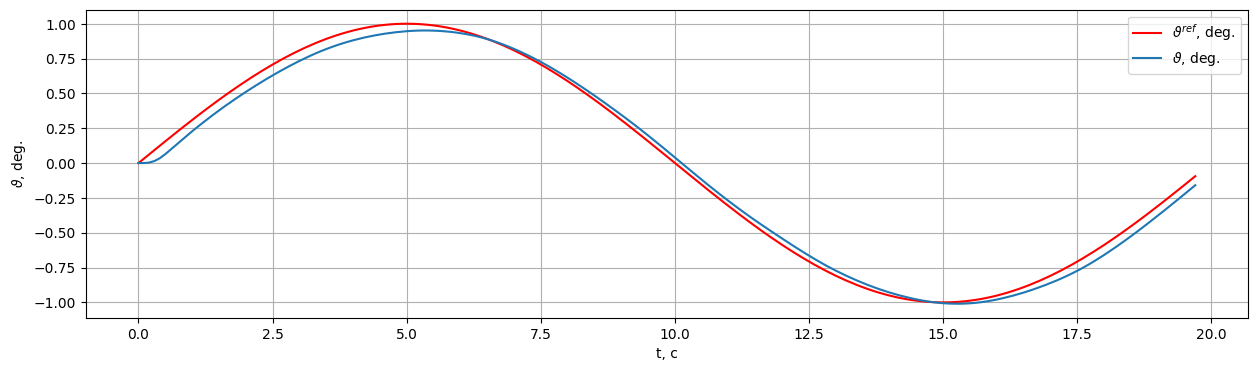

In [9]:
# Plot theta (pitch angle) tracking
env.unwrapped.model.plot_transient_process('theta', tps, reference_signals[0], to_deg=True, figsize=(15,4))

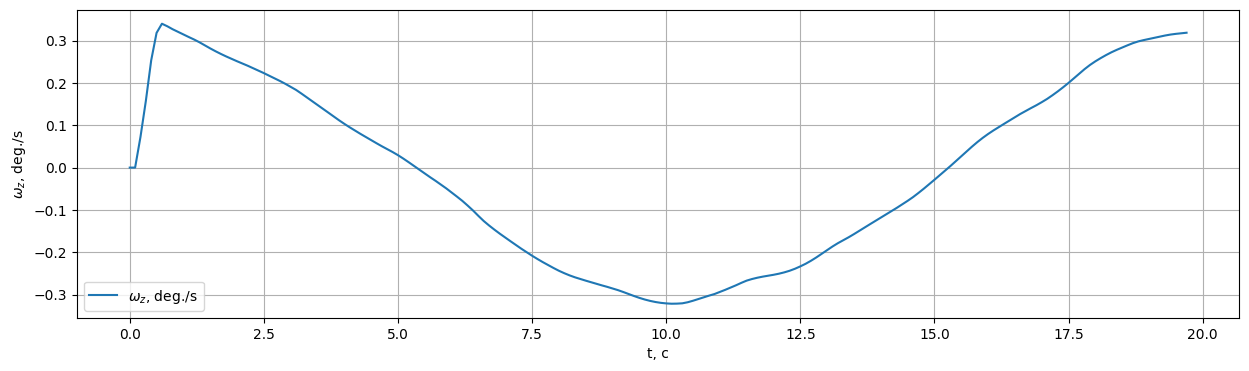

In [10]:
# Plot pitch rate (q)
env.unwrapped.model.plot_state(state_name='q', time=tps, to_deg=True, figsize=(15,4))


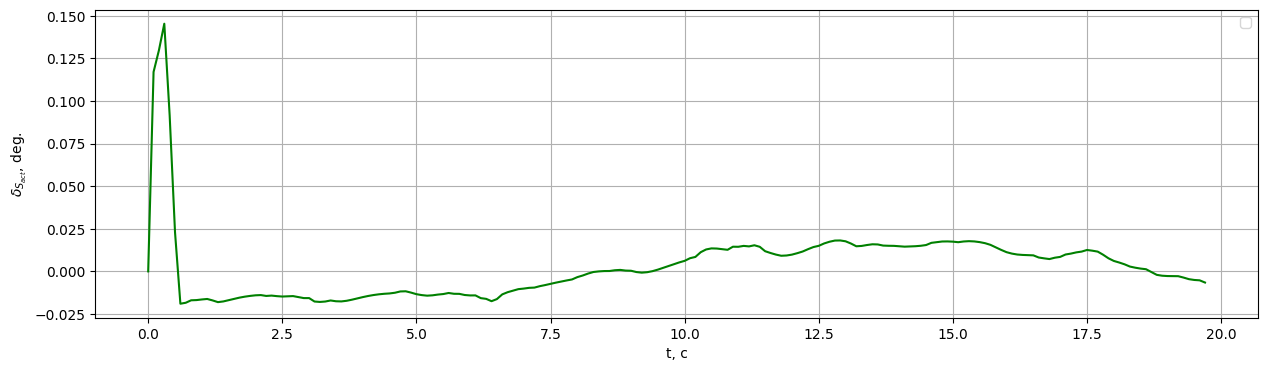

In [11]:
# Plot elevator control
env.unwrapped.model.plot_control(control_name='ele', time=tps, to_deg=True, figsize=(15,4))
